# 
# cad 도면을 읽어오기
# 변수화


In [13]:
import sys
import os

# 현재 작업 경로 확인 및 모듈 경로 추가
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# 만약 현재 경로가 sys.path에 없다면 추가
if current_dir not in sys.path:
    sys.path.append(current_dir)

# 워크스페이스 루트에서 실행되는 경우를 대비해 하위 폴더 경로도 명시적으로 추가
# (노트북이 tools/BanGeoCode_Python 안에 있다고 가정)
module_path = os.path.join(current_dir, 'tools', 'BanGeoCode_Python')
if os.path.exists(module_path) and module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added module path: {module_path}")


Current working directory: d:\KangDH\Emlab_emach


In [14]:

import matplotlib.pyplot as plt


In [15]:
import numpy as np
import time
from Geometry import generate_geometry
from Feasibility import check_feasibility

def Rnd(range_val, N):
    """
    Generate N random numbers within range_val [min, max].
    If range_val has 1 element, return that element repeated N times.
    """
    range_val = np.array(range_val)
    if len(range_val) > 1:
        return (range_val[1] - range_val[0]) * np.random.rand(N) + range_val[0]
    else:
        return np.full(N, range_val[0])

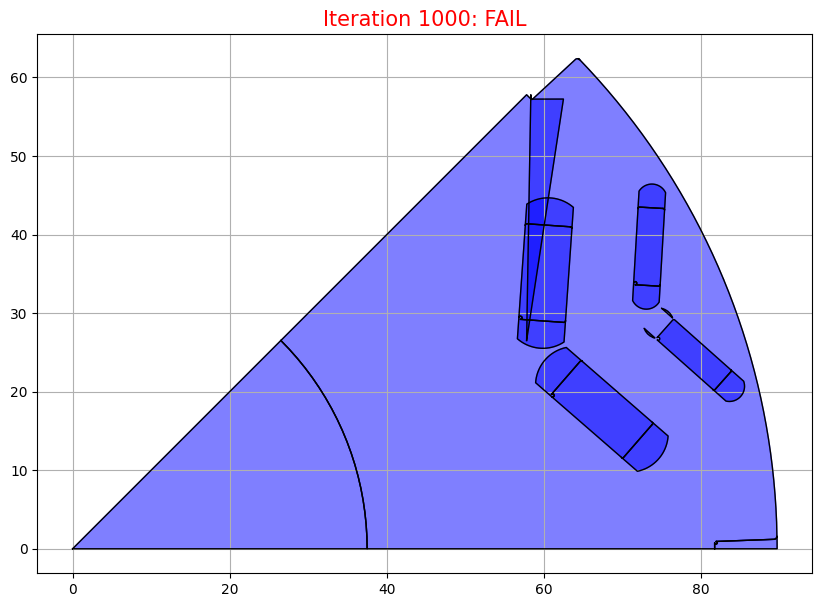

Iteration 1000: FAIL
Max iterations reached.
GIF saved as geometry_generation.gif
GIF saved as geometry_generation.gif


In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import io
from PIL import Image

n_iteration = 1
n_feasible = 0
max_feasible_designs = 1 # How many feasible designs to find

frames = [] # List to store images for GIF

print("Starting Random Geometry Generation...")

while n_feasible < max_feasible_designs:
    # Machine Parameters
    params = {}
    params['VMagnet_Layers'] = 2
    params['Pole_Number'] = 8
    params['Shaft_Dia'] = 75
    params['Slot_Number'] = 48
    params['Stator_Lam_Dia'] = 230
    params['Airgap'] = 0.71
    params['Shaft_Hole_Diameter'] = 0
    
    # Random Split Ratio
    split_ratio = Rnd([0.7, 0.8], 1)[0]
    params['Stator_Bore'] = round(split_ratio * params['Stator_Lam_Dia'], 1)
    
    lay = params['VMagnet_Layers']
    
    # Optimization variables
    params['MagnetThickness_Array'] = Rnd([2, 6], lay)
    
    # VSimpleWidth_Array
    w1 = Rnd([10, 15], 1)[0]
    w2 = Rnd([15, 20], 1)[0]
    params['VSimpleWidth_Array'] = np.array([w1, w2])
    
    params['VSimpleMagShift_Array'] = Rnd([0, 0], lay)
    
    # MagnetBarWidth_Array
    factor = Rnd([0.5, 1], 1)[0]
    params['MagnetBarWidth_Array'] = factor * params['VSimpleWidth_Array']
    
    # BridgeThickness_Array
    b1 = Rnd([1, 2], 1)[0]
    b2 = Rnd([10, 15], 1)[0]
    params['BridgeThickness_Array'] = np.array([b1, b2])
    
    # PoleVAngle_Array
    a1 = Rnd([120, 180], 1)[0]
    a2 = Rnd([100, 150], 1)[0]
    params['PoleVAngle_Array'] = np.array([a1, a2])
    
    params['VSimpleEndRegion_Outer_Array'] = Rnd([1, 1], lay)
    params['VSimpleEndRegion_Inner_Array'] = Rnd([1, 1], lay)
    params['VSimpleMagnetPost_Array'] = Rnd([0.1, 3], lay)
    params['VShape_Magnet_ClearanceOuter'] = Rnd([0, 0], lay)
    params['VShape_Magnet_ClearanceInner'] = Rnd([0, 0], lay)
    
    params['PoleNotchDepth'] = Rnd([1, 10], 1)[0]
    params['PoleNotchArc_Inner'] = Rnd([5, 20], 1)[0]
    params['PoleNotchArc_Outer'] = 1.2 * params['PoleNotchArc_Inner']
    
    params['r_10'] = Rnd([0, 1], 1)[0]
    params['r_11'] = Rnd([0, 1], 1)[0]
    params['r_M'] = 0.2
    
    try:
        shapes = generate_geometry(params)
        
        symmetry_angle = 360.0 / params['Pole_Number'] / 2.0
        is_feasible = check_feasibility(shapes, symmetry_angle)
        
        # Visualization
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 10))
        for shape in shapes:
            shape.plot(ax=ax)
        ax.set_aspect('equal')
        ax.grid(True)
        
        if is_feasible:
            ax.set_title(f"Iteration {n_iteration}: PASS", color='blue', fontsize=15)
            status_text = "PASS"
        else:
            ax.set_title(f"Iteration {n_iteration}: FAIL", color='red', fontsize=15)
            status_text = "FAIL"
        
        # Save frame to buffer
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        buf.seek(0)
        img = Image.open(buf)
        frames.append(img)
        
        plt.show()
        print(f"Iteration {n_iteration}: {status_text}")
        plt.close(fig) # Close figure to free memory

        if is_feasible:
            n_feasible += 1
            
    except Exception as e:
        print(f"Iteration {n_iteration}: Error - {e}")
    
    n_iteration += 1
    if n_iteration > 1000: # Safety break
        print("Max iterations reached.")
        break

# Save GIF
if frames:
    gif_filename = 'geometry_generation.gif'
    frames[0].save(gif_filename, format='GIF',
                   append_images=frames[1:],
                   save_all=True,
                   duration=500, # 500 ms per frame
                   loop=0)
    print(f"GIF saved as {gif_filename}")